# Polished two-class Venn diagrams

A small, reusable `matplotlib` + `matplotlib-venn` example. Edit the values in the next cell;
the remaining cells validate the counts and handle the styling.

The inputs are **total membership in class A**, **total membership in class B**, and their
**intersection**. The exclusive regions are calculated automatically.

Dependency: `matplotlib-venn`. It is intentionally not installed automatically from this
notebook; if your selected kernel lacks it, install it into that environment once with
`python -m pip install matplotlib-venn`.

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
try:
    from matplotlib_venn import venn2, venn2_circles
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        "This notebook requires matplotlib-venn. Install it in the active kernel "
        "with: python -m pip install matplotlib-venn"
    ) from error

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titleweight": "bold",
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

## Edit this cell

The example values are deliberately in the low-to-mid hundreds. Set `SHOW_PERCENTAGES = True`
to annotate each region with its percentage of the union.

In [23]:
def plot_two_class_venn(
    class_a_total,
    class_b_total,
    overlap,
    *,
    labels=("Class A", "Class B"),
    title="Overlap between two classes",
    subtitle=None,
    palette=None,
    show_percentages=False,
    ax=None,
):
    """Plot a two-set Venn from class totals and their intersection."""
    values = (class_a_total, class_b_total, overlap)
    if any(int(value) != value or value < 0 for value in values):
        raise ValueError("Counts must be non-negative integers.")
    class_a_total, class_b_total, overlap = map(int, values)
    if overlap > min(class_a_total, class_b_total):
        raise ValueError("Overlap cannot exceed either class total.")

    default_palette = {
        "class_a": "#4C78A8", "class_b": "#E76F51",
        "overlap": "#8B6F91", "outline": "#263238",
        "text": "#263238", "background": "#FFFFFF",
    }
    colors = {**default_palette, **(palette or {})}
    only_a = class_a_total - overlap
    only_b = class_b_total - overlap
    region_counts = {"10": only_a, "01": only_b, "11": overlap}
    union = only_a + only_b + overlap

    if ax is None:
        _, ax = plt.subplots(figsize=(7.4, 6.2))
    ax.figure.patch.set_facecolor(colors["background"])
    ax.set_facecolor(colors["background"])

    diagram = venn2(
        subsets=(only_a, only_b, overlap),
        set_labels=labels,
        set_colors=(colors["class_a"], colors["class_b"]),
        alpha=0.90,
        ax=ax,
    )
    venn2_circles(
        subsets=(only_a, only_b, overlap),
        color=colors["outline"], linewidth=1.5, linestyle="solid", ax=ax,
    )

    region_colors = {
        "10": colors["class_a"],
        "01": colors["class_b"],
        "11": colors["overlap"],
    }
    for region_id, count in region_counts.items():
        patch = diagram.get_patch_by_id(region_id)
        label = diagram.get_label_by_id(region_id)
        if patch is not None:
            patch.set_color(region_colors[region_id])
            patch.set_alpha(0.92)
        if label is not None:
            if not show_percentages:
                annotation = f" {count} cells"
            elif show_percentages and union:
                annotation = f" {count} cells \n ({count/union:.0%})"
            label.set_text(annotation)
            label.set_color("white")
            label.set_fontsize(15 if not show_percentages else 12.5)
            label.set_fontweight("bold")

    for set_label in diagram.set_labels or []:
        set_label.set_color(colors["text"])
        set_label.set_fontsize(13)
        set_label.set_fontweight("semibold")

    ax.set_title(title, color=colors["text"], fontsize=17, pad=24)
    if subtitle:
        ax.text(
            0.5, 1.01, subtitle, transform=ax.transAxes, ha="center", va="bottom",
            color=colors["text"], fontsize=10.5, alpha=0.72,
        )
    ax.text(
        0.5, -0.06, f"Union: {union:,}", transform=ax.transAxes, ha="center",
        color=colors["text"], fontsize=10.5, alpha=0.72,
    )
    return ax


## Primary figure

This cell uses only the manually editable settings above.

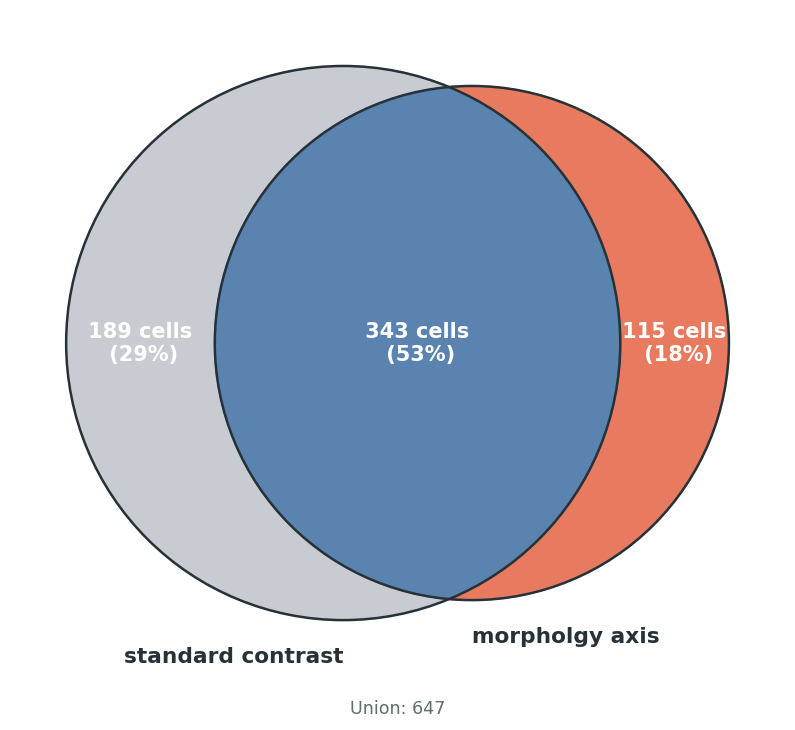

In [39]:
# Membership counts
CLASS_A_TOTAL = 189 + 343
CLASS_B_TOTAL = 115 + 343
OVERLAP = 343

# Labels and title
CLASS_A_LABEL = "standard contrast"
CLASS_B_LABEL = "morpholgy axis"
TITLE = ""
SUBTITLE = ""

# Muted blue + coral, with a distinct plum overlap on a warm-white background
PALETTE = {
    "class_a": "#C4C8CE",
    "class_b": "#E76F51",
    "overlap": "#4C78A8", ##8B6F91",
    "outline": "#263238",
    "text": "#263238",
    "background": "#FFFFFF",
}

# Alternative palettes: uncomment one line to replace PALETTE above.
# Colorblind-safe blue / vermillion / magenta
# PALETTE = {"class_a": "#0072B2", "class_b": "#D55E00", "overlap": "#CC79A7", "outline": "#222222", "text": "#222222", "background": "#FFFFFF"}
# Electric cobalt / hot pink / violet
# PALETTE = {"class_a": "#3A86FF", "class_b": "#FF006E", "overlap": "#8338EC", "outline": "#202238", "text": "#202238", "background": "#FFFFFF"}
# Deep teal / saffron / aubergine
# PALETTE = {"class_a": "#1B7F79", "class_b": "#E9B44C", "overlap": "#6D3A72", "outline": "#243238", "text": "#243238", "background": "#FFFFFF"}
# Ocean blue / seafoam / indigo
# PALETTE = {"class_a": "#277DA1", "class_b": "#43AA8B", "overlap": "#5A4E9C", "outline": "#253237", "text": "#253237", "background": "#FFFFFF"}
# Raspberry / apricot / dark plum
# PALETTE = {"class_a": "#C9184A", "class_b": "#F4A261", "overlap": "#6D597A", "outline": "#352F36", "text": "#352F36", "background": "#FFFFFF"}

SHOW_PERCENTAGES = True
SAVE_FIGURE = True
OUTPUT_FILE = Path("figures/full_overlap.png")

fig, ax = plt.subplots(figsize=(7.4, 6.2))
plot_two_class_venn(
    CLASS_A_TOTAL, CLASS_B_TOTAL, OVERLAP,
    labels=(CLASS_A_LABEL, CLASS_B_LABEL),
    title=TITLE, subtitle=SUBTITLE, palette=PALETTE,
    show_percentages=SHOW_PERCENTAGES, ax=ax,
)
fig.tight_layout()
if SAVE_FIGURE:
    OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_FILE, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

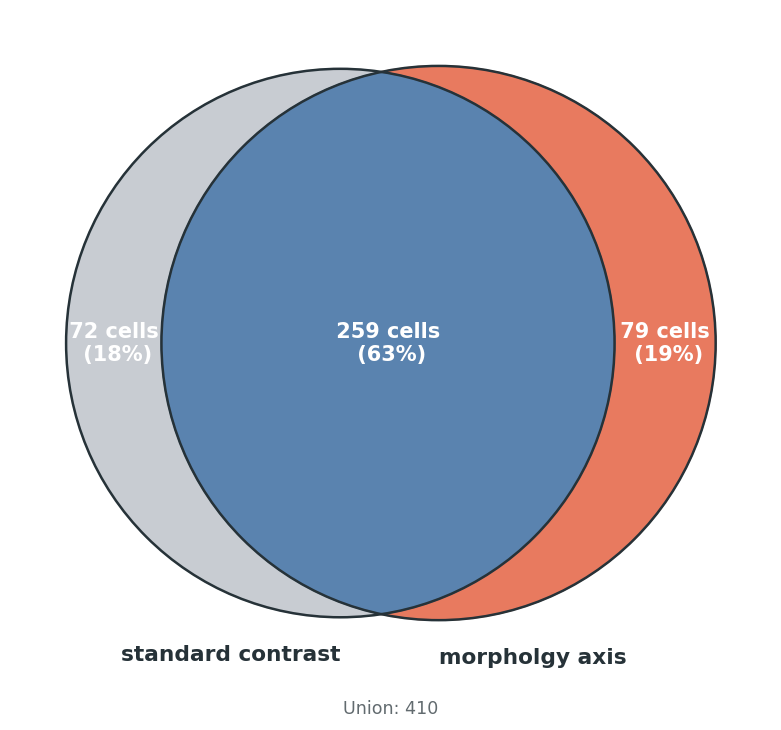

In [40]:
# Membership counts
CLASS_A_TOTAL = 72 + 259
CLASS_B_TOTAL = 79 + 259
OVERLAP = 259

# Labels and title
CLASS_A_LABEL = "standard contrast"
CLASS_B_LABEL = "morpholgy axis"
TITLE = ""
SUBTITLE = ""
OUTPUT_FILE = Path("figures/valid_overlap.png")

fig, ax = plt.subplots(figsize=(7.4, 6.2))
plot_two_class_venn(
    CLASS_A_TOTAL, CLASS_B_TOTAL, OVERLAP,
    labels=(CLASS_A_LABEL, CLASS_B_LABEL),
    title=TITLE, subtitle=SUBTITLE, palette=PALETTE,
    show_percentages=SHOW_PERCENTAGES, ax=ax,
)
fig.tight_layout()
if SAVE_FIGURE:
    OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_FILE, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## Two annotation styles

A side-by-side preview of count-only and count-plus-percentage labeling.

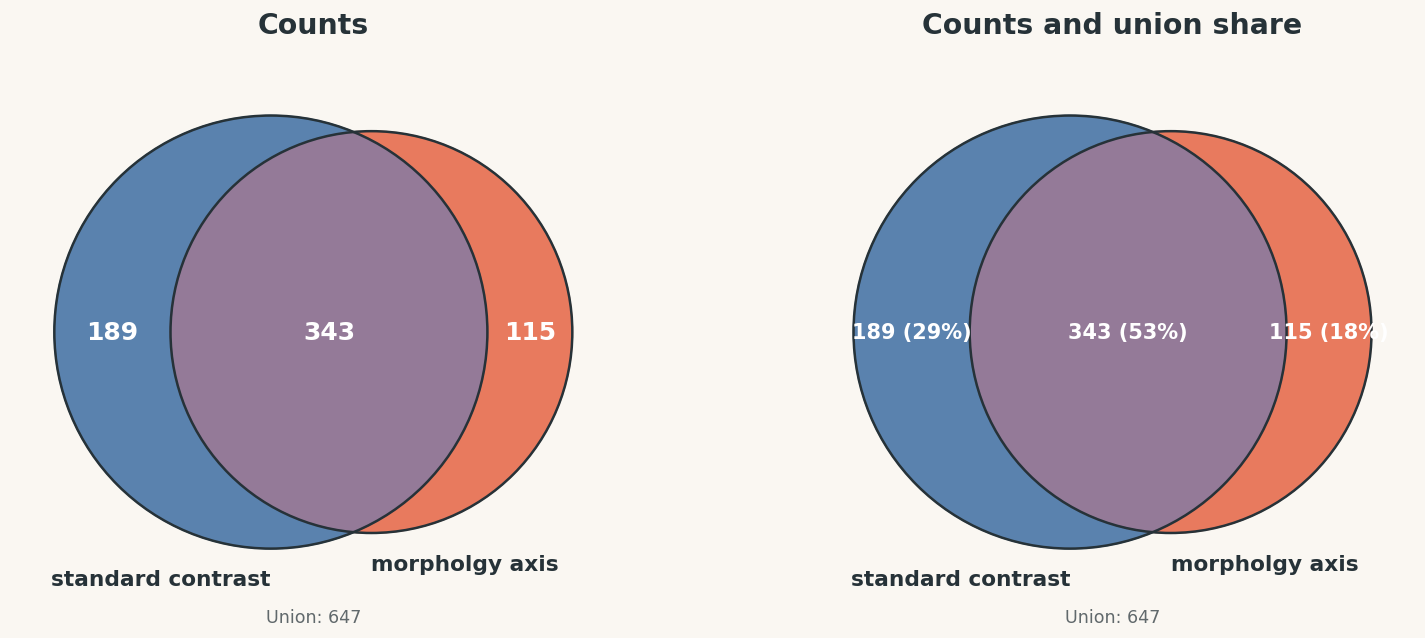

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))
for ax, percentages, panel_title in zip(
    axes, (False, True), ("Counts", "Counts and union share")
):
    plot_two_class_venn(
        CLASS_A_TOTAL, CLASS_B_TOTAL, OVERLAP,
        labels=(CLASS_A_LABEL, CLASS_B_LABEL),
        title=panel_title, subtitle=SUBTITLE, palette=PALETTE,
        show_percentages=percentages, ax=ax,
    )
fig.patch.set_facecolor(PALETTE["background"])
fig.suptitle(TITLE, fontsize=18, fontweight="bold", color=PALETTE["text"], y=1.02)
fig.tight_layout()
plt.show()